# El abuso financiero, visto desde los registros del banco

**74,5 % contra 39,9 %.** Esa es la proporción de mujeres que pagaron al menos un cargo por
sobregiro en el año antes de contarle a su banco que sufrían abuso financiero, frente a clientas
parecidas que no habían reportado nada.

¿Qué más se ve en una cuenta bancaria cuando otra persona controla tu dinero?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Trendl et al. (2026), *Nature* — «Banking records reveal characteristics of financial abuse»
**DOI:** [10.1038/s41586-026-11049-7](https://doi.org/10.1038/s41586-026-11049-7)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-23-abuso-financiero-registros-bancarios/notebook.ipynb)

**Video:** [Pendiente]

El abuso financiero es una forma de violencia doméstica: alguien controla el dinero de otra persona,
le quita el acceso a sus cuentas, la endeuda o vigila cada gasto. Es difícil de documentar, y casi todo
lo que sabíamos venía de encuestas pequeñas.

El equipo usó registros anonimizados de un gran banco del Reino Unido: 5.428 mujeres que le contaron al
banco que sufrían abuso financiero (las llamaremos **víctimas-sobrevivientes**) y 15.602 clientas sin
ninguna revelación conocida (así llama el estudio al momento en que la clienta se lo cuenta al banco), emparejadas para parecerse a ellas 7 años antes (edad, ingresos, crédito,
productos). Siguieron 373 indicadores financieros durante esos 7 años.

Los movimientos de cada persona son confidenciales. Lo que tenemos aquí son las tablas suplementarias
del paper: medias, intervalos de confianza y pruebas de cada indicador. Alcanza para ver el patrón.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PERIODO = 'ultimo_anio'   # ventana: '7_a_3.5_anios', '3.5_a_0_anios' o 'ultimo_anio'
UMBRAL_P = 0.01           # p ajustada (Benjamini-Hochberg) que usa el paper para "significativo"
FUENTE = ('Fuente: Trendl et al. (2026), Nature | Datos: Supplementary Tables 3–8 (MOESM3), '
          'estadísticos agregados; los registros individuales son confidenciales')
COLOR_VICTIMAS = '#DC2626'
COLOR_CONTROL = '#2563EB'
COLOR_REFERENCIA = '#D97706'
COLOR_GRIS = '#BBBBBB'
SLUG = '2026-09-23-abuso-financiero-registros-bancarios'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo editorial CaM (local → fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga (descarga desde el repo si no están en local) ──────
os.makedirs('datos', exist_ok=True)
for f in ['diferencias_373_indicadores.csv', 'sensibilidad_tres_muestras_ultimo_anio.csv',
          'referencia_poblacion_banco.csv', 'balance_emparejamiento.csv']:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{f}', f'datos/{f}')
dif = pd.read_csv('datos/diferencias_373_indicadores.csv')              # muestra principal: 373 indicadores × 3 ventanas
sens = pd.read_csv('datos/sensibilidad_tres_muestras_ultimo_anio.csv')  # último año con 3 grupos control distintos
ref = pd.read_csv('datos/referencia_poblacion_banco.csv')               # medias descriptivas de la clientela del banco
bal = pd.read_csv('datos/balance_emparejamiento.csv')                   # balance del emparejamiento (SI Table 8)


def es(x, dec=1):
    """Número en formato español: miles con punto, decimales con coma."""
    s = f'{x:,.{dec}f}'
    return s.replace(',', '_').replace('.', ',').replace('_', '.')


NOMBRE_PERIODO = {'7_a_3.5_anios': 'entre 7 y 3,5 años antes de la revelación',
                  '3.5_a_0_anios': 'entre 3,5 y 0 años antes de la revelación',
                  'ultimo_anio': 'último año antes de la revelación'}
PERIODOS = ['7_a_3.5_anios', '3.5_a_0_anios', 'ultimo_anio']

ult = dif[dif['periodo'] == PERIODO]
sig = ult[ult['p_ajustada_bh'] < UMBRAL_P]
n_vs = int(ult['n_vs'].mode()[0])
n_ctl = int(ult['n_control'].mode()[0])
n_trans = (ult['tipo_medida'] == 'transaccional').sum()

print(f'Víctimas-sobrevivientes: {es(n_vs, 0)} · control emparejado: {es(n_ctl, 0)}')
print(f'Pruebas en la muestra principal (3 ventanas, corregidas juntas): {es(dif["p_permutacion"].notna().sum(), 0)}')
print(f'Indicadores: {ult["indicador"].nunique()} ({n_trans} transaccionales, {len(ult) - n_trans} no transaccionales)')
print(f'Con p ajustada < {es(UMBRAL_P, 2)} ({NOMBRE_PERIODO[PERIODO]}): {len(sig)} — '
      f'{(sig["diferencia"] > 0).sum()} más altos en víctimas, {(sig["diferencia"] < 0).sum()} más altos en el control')
edad = bal[bal['covariable'] == 'AGE_AT_START']
for _, fila in edad.iterrows():
    momento = fila['momento'].replace('_', ' ').replace('despues', 'después')
    print(f'Edad media {momento}: víctimas {es(fila["media_vs"])} · '
          f'control {es(fila["media_control"])} · diferencia estandarizada {es(fila["dif_media_estandarizada"], 2)}')

Víctimas-sobrevivientes: 5.428 · control emparejado: 15.602
Pruebas en la muestra principal (3 ventanas, corregidas juntas): 1.117
Indicadores: 373 (353 transaccionales, 20 no transaccionales)
Con p ajustada < 0,01 (último año antes de la revelación): 161 — 87 más altos en víctimas, 74 más altos en el control
Edad media antes del emparejamiento: víctimas 35,2 · control 44,5 · diferencia estandarizada -0,78
Edad media después del emparejamiento: víctimas 35,3 · control 34,9 · diferencia estandarizada 0,03


Aquí está.

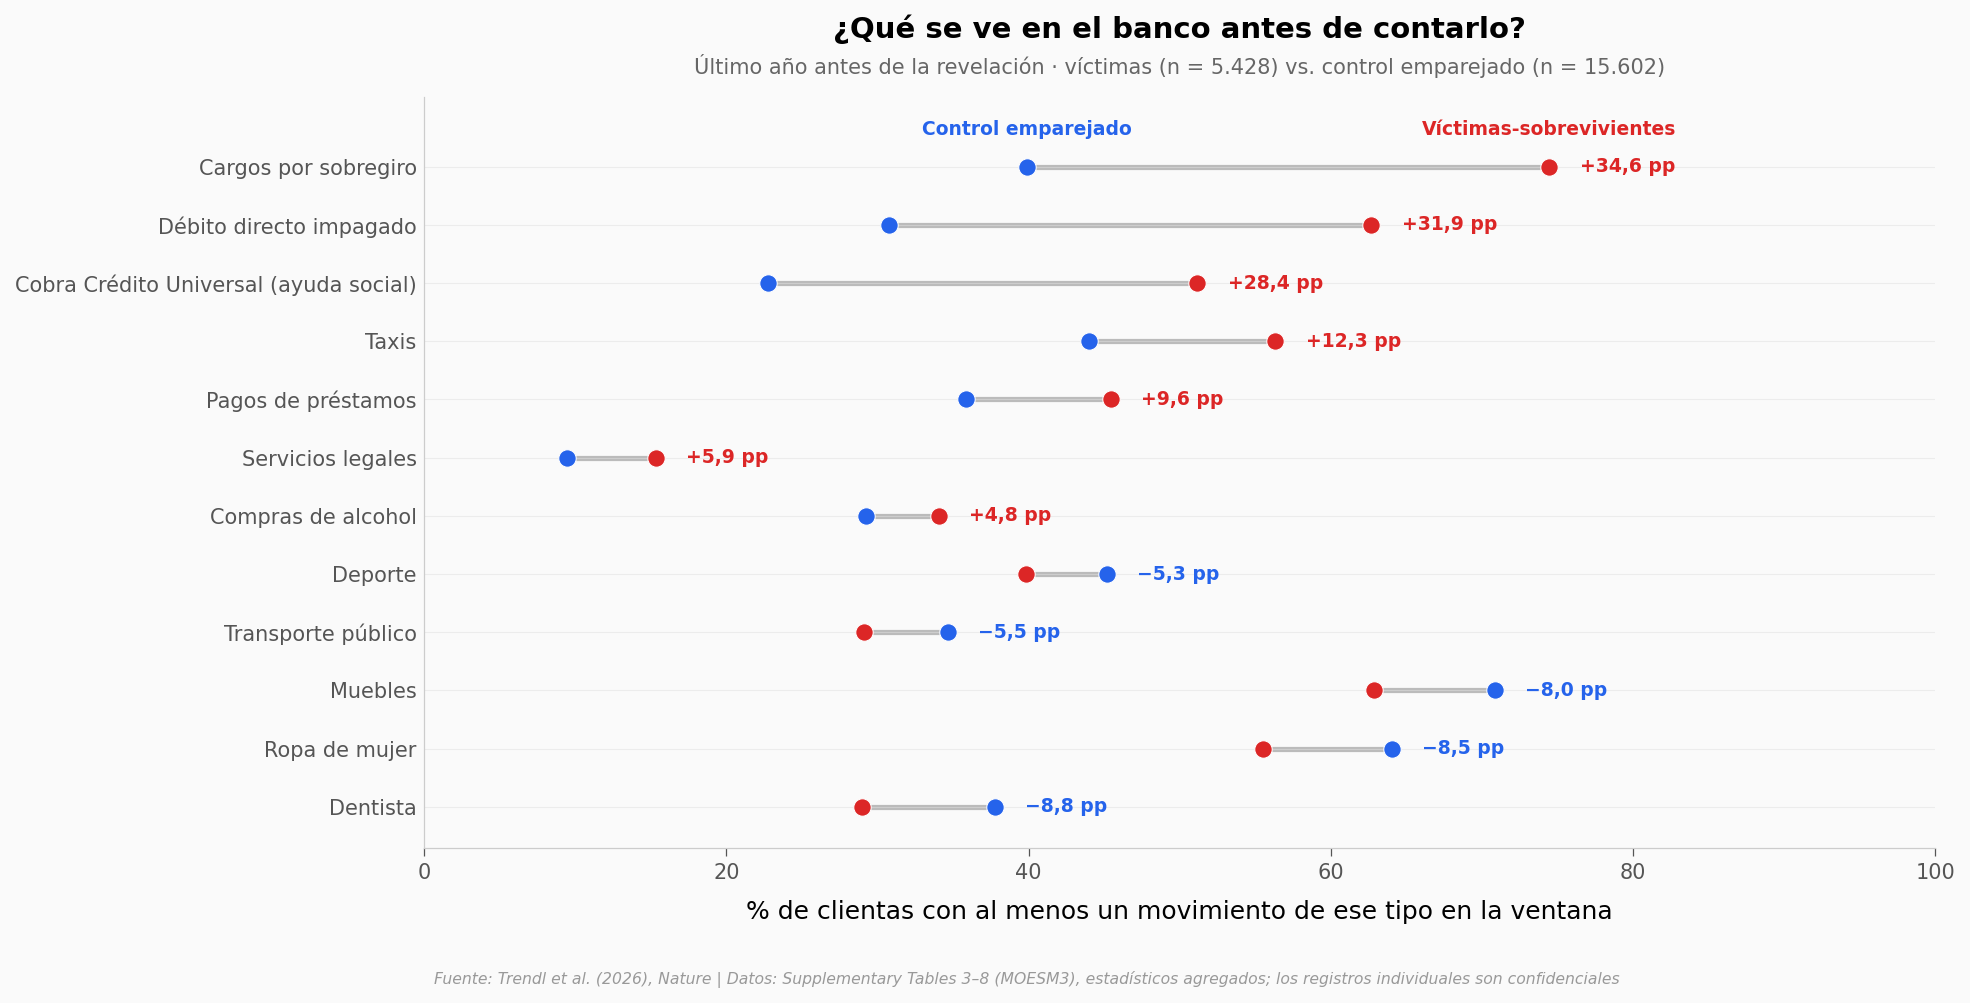

Cargos por sobregiro: 74,5 % vs. 39,9 % → 34,6 pp (IC 95 %: 33,2 a 36,0) · h ≈ 0,71
Débito directo impagado: 62,7 % vs. 30,8 % → 31,9 pp (IC 95 %: 30,4 a 33,4) · h ≈ 0,65
Cobra Crédito Universal (ayuda social): 51,2 % vs. 22,8 % → 28,4 pp (IC 95 %: 26,9 a 29,9) · h ≈ 0,60
Los 12 indicadores tienen p ajustada < 0,001 (prueba de permutación)


In [2]:
SELECCION = {  # nombre del indicador en el banco → etiqueta en español
    'LBG Overdraft charges': 'Cargos por sobregiro',
    'Unpaid DD': 'Débito directo impagado',
    'Benefits/Universal Credit/Other': 'Cobra Crédito Universal (ayuda social)',
    'Travel/Taxis/Other': 'Taxis',
    'Financial Services/Loans/Other': 'Pagos de préstamos',
    'Services/Professional/Legal': 'Servicios legales',
    'Retail/Food & Drink/Alcohol': 'Compras de alcohol',
    'Travel/Commuter/Other': 'Transporte público',
    'Hobbies & Interests/Sport/Other': 'Deporte',
    'Retail/Furniture/Other': 'Muebles',
    'Retail/Clothing/Women': 'Ropa de mujer',
    'Services/Health/Dental': 'Dentista',
}
NOMBRES = {**SELECCION, 'Planned Overdraft': 'Sobregiro autorizado', 'Credit Score': 'Puntaje de crédito',
           'Savings Balance': 'Ahorro'}
h = ult[ult['indicador'].isin(SELECCION)].copy()
h['etiqueta'] = h['indicador'].map(SELECCION)
h = h.sort_values('diferencia').reset_index(drop=True)
y = np.arange(len(h))

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.hlines(y, h['control_media'] * 100, h['vs_media'] * 100, color=COLOR_GRIS, lw=2.5, zorder=1)
ax.scatter(h['control_media'] * 100, y, color=COLOR_CONTROL, s=70, zorder=3, edgecolors='white', linewidths=0.5)
ax.scatter(h['vs_media'] * 100, y, color=COLOR_VICTIMAS, s=70, zorder=3, edgecolors='white', linewidths=0.5)
for yi, r in h.iterrows():
    dpp = r['diferencia'] * 100
    x_txt = max(r['vs_media'], r['control_media']) * 100 + 2
    ax.text(x_txt, yi, f'{"+" if dpp > 0 else "−"}{es(abs(dpp))} pp', va='center', fontsize=9,
            fontweight='bold', color=COLOR_VICTIMAS if dpp > 0 else COLOR_CONTROL)
arriba = h.iloc[-1]
ax.text(arriba['vs_media'] * 100, y[-1] + 0.55, 'Víctimas-sobrevivientes', color=COLOR_VICTIMAS,
        ha='center', fontsize=9, fontweight='bold')
ax.text(arriba['control_media'] * 100, y[-1] + 0.55, 'Control emparejado', color=COLOR_CONTROL,
        ha='center', fontsize=9, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(h['etiqueta'], fontsize=10)
ax.set_ylim(-0.7, y[-1] + 1.2)
ax.set_xlim(0, 100)
ax.set_xlabel('% de clientas con al menos un movimiento de ese tipo en la ventana')
ax.set_title('¿Qué se ve en el banco antes de contarlo?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{NOMBRE_PERIODO[PERIODO].capitalize()} · víctimas (n = {es(n_vs, 0)}) vs. '
        f'control emparejado (n = {es(n_ctl, 0)})', transform=ax.transAxes, fontsize=10,
        color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_diferencias_ultimo_anio.png', dpi=200, bbox_inches='tight')
plt.show()

for _, r in h.sort_values('diferencia', ascending=False).head(3).iterrows():
    print(f'{r["etiqueta"]}: {es(r["vs_media"] * 100)} % vs. {es(r["control_media"] * 100)} % → '
          f'{es(r["diferencia"] * 100)} pp (IC 95 %: {es(r["dif_ic95_inf"] * 100)} a {es(r["dif_ic95_sup"] * 100)}) · '
          f'h ≈ {es(r["tamano_efecto"], 2)}')
if (h['p_ajustada_bh'] < 0.001).all():
    print(f'Los {len(h)} indicadores tienen p ajustada < 0,001 (prueba de permutación)')

Las tres brechas más grandes tienen que ver con dinero que no alcanza. El 74,5 % de las
víctimas-sobrevivientes pagó algún cargo por sobregiro en el último año, frente al 39,9 % del control:
34,6 puntos porcentuales más (h ≈ 0,71). Los débitos directos impagados (cobros automáticos que
rebotan por falta de fondos) suben 31,9 puntos (h ≈ 0,65), y cobrar Crédito Universal, la principal
ayuda social británica, 28,4 puntos (51,2 % contra 22,8 %; h ≈ 0,60).

Del lado contrario, hay gastos que aparecen en menos cuentas: dentista (−8,8 puntos), ropa de mujer (−8,5),
muebles (−8,0), deporte (−5,3). Y otros que aparecen en más: taxis (+12,3) y servicios legales (+5,9),
mientras el transporte público baja (−5,5).

Las compras de alcohol también aparecen en más cuentas (+4,8 puntos): es la proporción de
clientas con al menos una compra en la cuenta, no cuánto se compra ni quién lo consume.

Dos precauciones. Es la proporción de clientas con al menos un movimiento de ese tipo, no cuánto gastan.
Y es un estudio observacional: las víctimas-sobrevivientes entraron al estudio porque se lo contaron al
banco, así que estos números describen a quienes hablaron, no a todas las víctimas, y no dicen qué
causó cada diferencia.

¿Esto aparece de golpe, justo antes de contárselo al banco, o se va acumulando?

Veamos tres indicadores que el banco mide como promedio por persona —puntaje de crédito, ahorro y
sobregiro autorizado (*planned overdraft*)— en las dos ventanas de 3,5 años antes de la revelación,
más el último año.

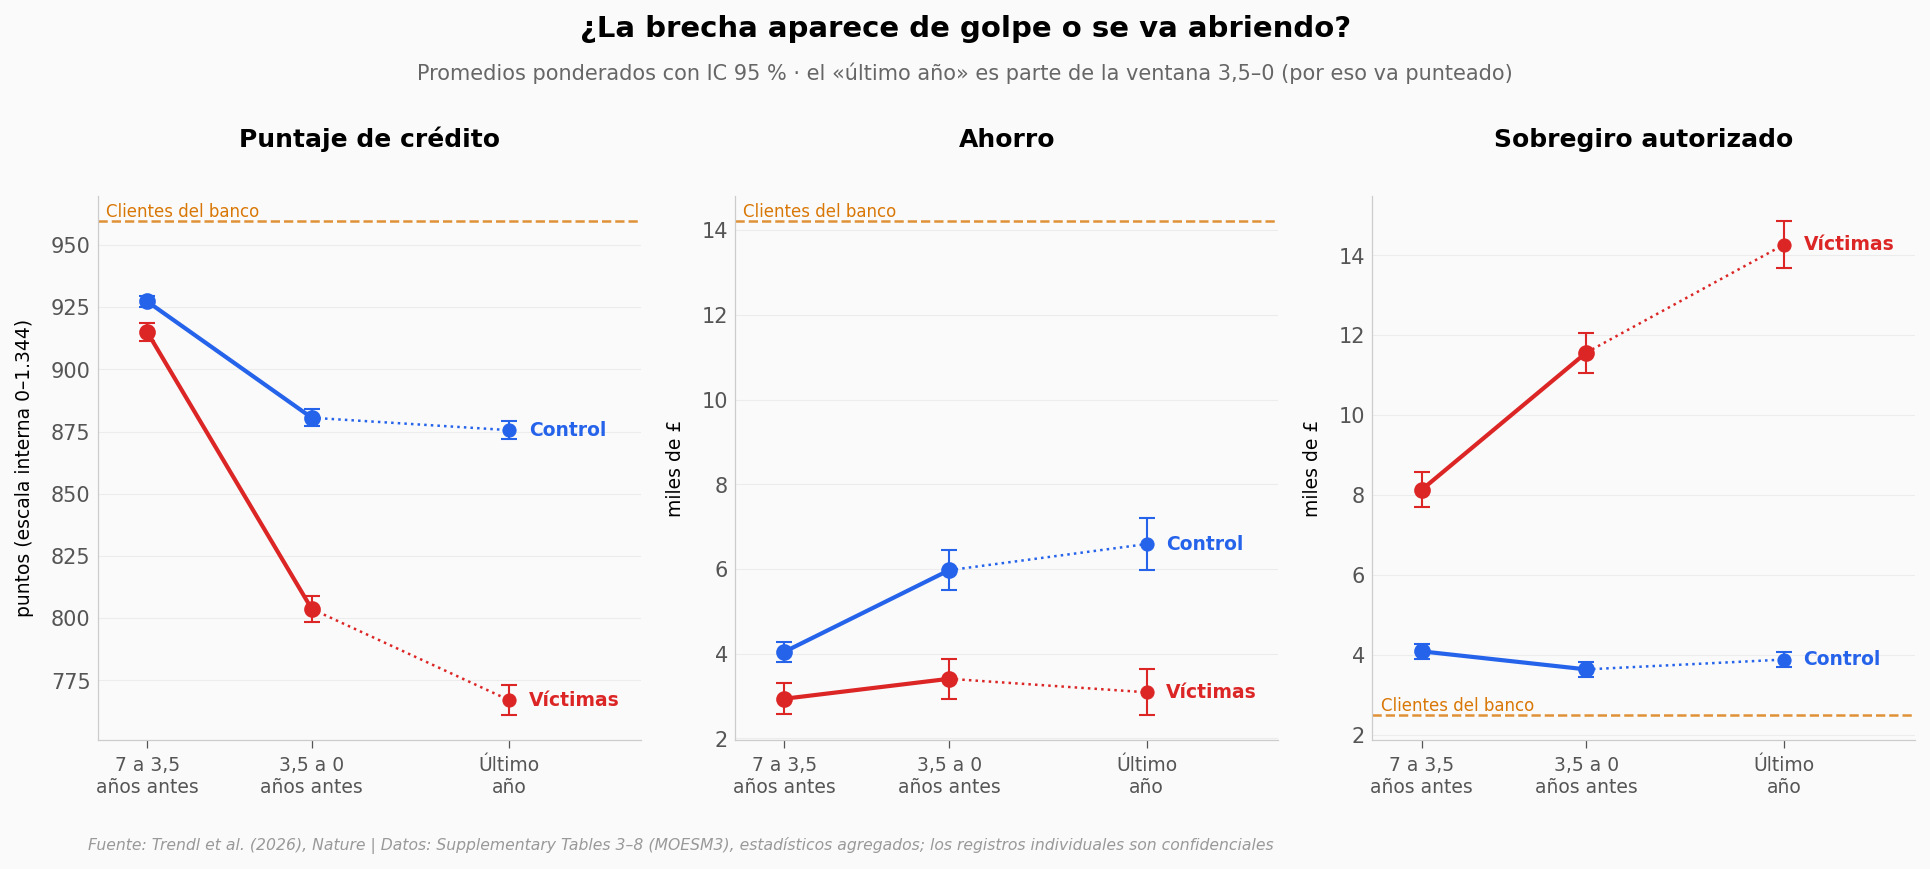

Puntaje de crédito: diferencia víctimas − control por ventana: -12 → -77 → -109 · último año 767 vs. 876 · clientes del banco 960 · n último año 5.428 / 15.602 · d ≈ -0,48
Ahorro: diferencia víctimas − control por ventana: -1.109 → -2.565 → -3.501 · último año 3.088 vs. 6.589 · clientes del banco 14.215 · n último año 4.149 / 12.181 · d ≈ -0,15
Sobregiro autorizado: diferencia víctimas − control por ventana: 4.048 → 7.934 → 10.389 · último año 14.268 vs. 3.879 · clientes del banco 2.488 · n último año 5.428 / 15.602 · d ≈ 0,52


In [3]:
ETIQUETAS_X = ['7 a 3,5\naños antes', '3,5 a 0\naños antes', 'Último\naño']
PANELES = [('Credit Score', 'Puntaje de crédito', 1, 'puntos (escala interna 0–1.344)'),
           ('Savings Balance', 'Ahorro', 1 / 1000, 'miles de £'),
           ('Planned Overdraft', 'Sobregiro autorizado', 1 / 1000, 'miles de £')]
banco = ref[ref['poblacion'] == 'clientes_banco'].set_index('indicador')['media']
x = np.array([0, 1, 2.2])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
for ax, (ind, nombre, f, unidad) in zip(axes, PANELES):
    s = dif[dif['indicador'] == ind].set_index('periodo').loc[PERIODOS]
    for grupo, color, etiqueta in [('vs', COLOR_VICTIMAS, 'Víctimas'), ('control', COLOR_CONTROL, 'Control')]:
        m = s[f'{grupo}_media'].values * f
        lo = s[f'{grupo}_ic95_inf'].values * f
        hi = s[f'{grupo}_ic95_sup'].values * f
        ax.plot(x[:2], m[:2], color=color, lw=2, marker='o', zorder=4)
        ax.plot(x[1:], m[1:], color=color, lw=1.2, ls=':', zorder=3)
        ax.scatter(x[2], m[2], color=color, s=40, zorder=5)
        ax.errorbar(x, m, yerr=[m - lo, hi - m], fmt='none', ecolor=color, capsize=4, lw=1, zorder=3)
        ax.text(x[2] + 0.12, m[2], etiqueta, color=color, fontsize=9, fontweight='bold', va='center')
    ax.axhline(banco[ind] * f, color=COLOR_REFERENCIA, ls='--', lw=1.2, alpha=0.8)
    ax.text(-0.25, banco[ind] * f, 'Clientes del banco', color=COLOR_REFERENCIA, fontsize=8, va='bottom')
    ax.set_xticks(x)
    ax.set_xticklabels(ETIQUETAS_X, fontsize=9)
    ax.set_xlim(-0.3, 3.0)
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_ylabel(unidad, fontsize=9)
fig.tight_layout()
fig.suptitle('¿La brecha aparece de golpe o se va abriendo?', fontsize=14, fontweight='bold', y=1.12)
fig.text(0.5, 1.03, 'Promedios ponderados con IC 95 % · el «último año» es parte de la ventana 3,5–0 '
         '(por eso va punteado)', ha='center', fontsize=10, color='#666666')
fig.text(0.05, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/trayectoria_credito_ahorro_sobregiro.png', dpi=200, bbox_inches='tight')
plt.show()

for ind, nombre, _, _ in PANELES:
    s = dif[dif['indicador'] == ind].set_index('periodo').loc[PERIODOS]
    difs = ' → '.join(es(v, 0) for v in s['diferencia'])
    print(f'{nombre}: diferencia víctimas − control por ventana: {difs} · último año {es(s.loc["ultimo_anio", "vs_media"], 0)} '
          f'vs. {es(s.loc["ultimo_anio", "control_media"], 0)} · clientes del banco {es(banco[ind], 0)} · '
          f'n último año {es(s.loc["ultimo_anio", "n_vs"], 0)} / {es(s.loc["ultimo_anio", "n_control"], 0)} · '
          f'd ≈ {es(s.loc["ultimo_anio", "tamano_efecto"], 2)}')

Las tres brechas se abren con el tiempo. El puntaje de crédito del grupo de víctimas-sobrevivientes queda
12 puntos por debajo del control entre 7 y 3,5 años antes, 77 puntos entre 3,5 y 0 años, y 109 en el
último año (767 contra 876, en la escala interna del banco). La diferencia de ahorro pasa de −£1.109 a
−£2.565 y a −£3.501; la de sobregiro autorizado, de +£4.048 a +£7.934 y a +£10.389. En tamaño de
efecto aproximado del último año: puntaje d ≈ −0,48, sobregiro autorizado d ≈ 0,52 y ahorro
d ≈ −0,15, muy pequeño pese a la cifra en libras.

La línea naranja da contexto: la clientela general del banco tiene un puntaje medio de 960 y £14.215
de ahorro. Es contexto, no un grupo emparejado.

¿Pasa lo mismo con el resto? Tomemos los 161 indicadores que salen significativos el último año (p ajustada < 0,01) y
comparemos el tamaño de su diferencia en las dos ventanas de igual largo.

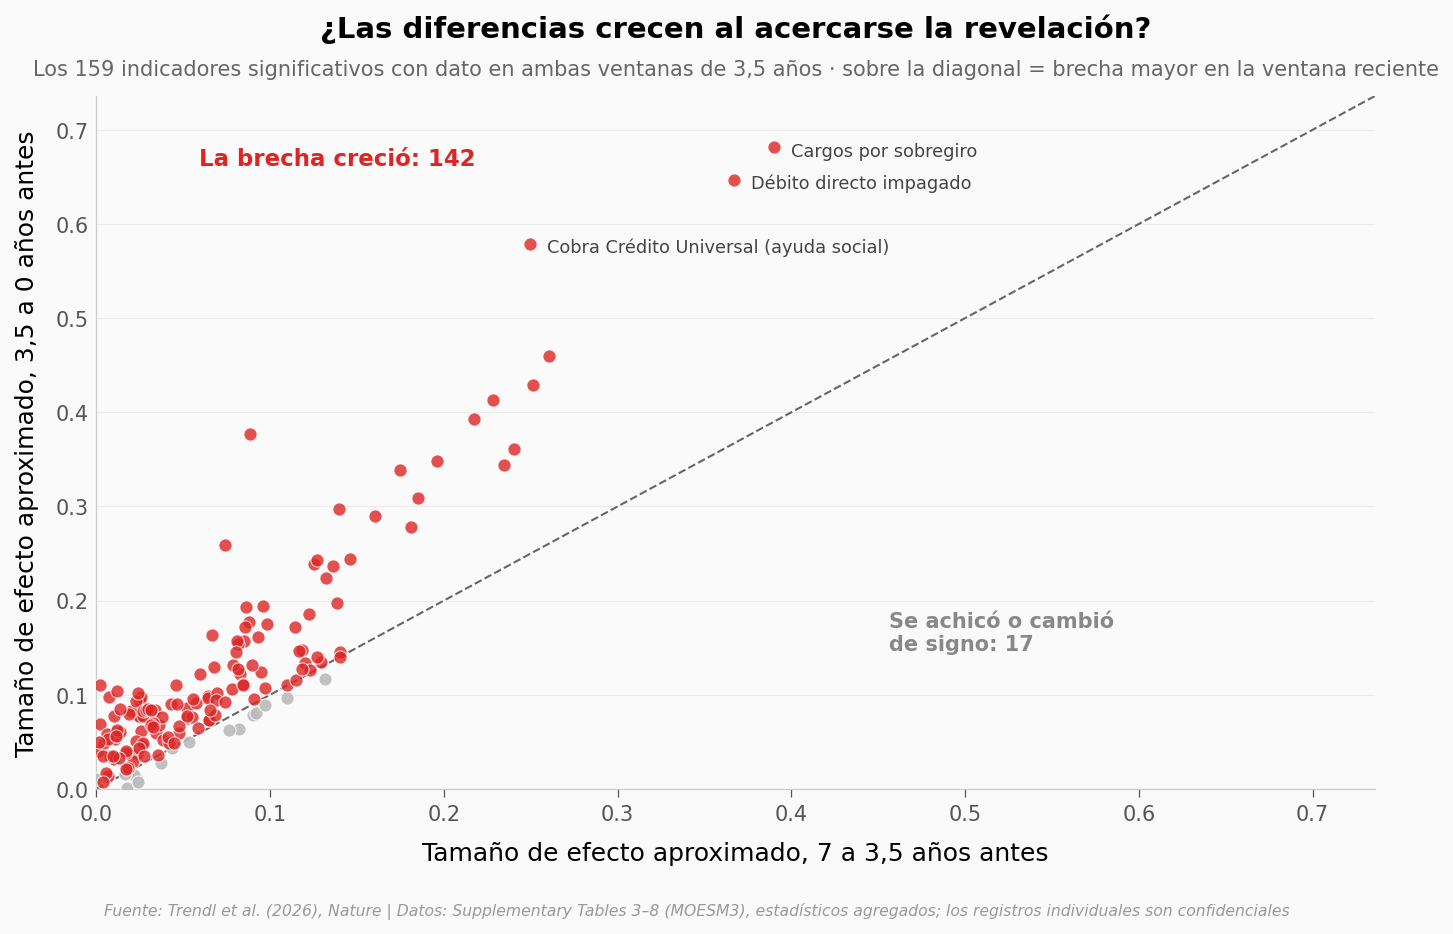

Significativos: 161 · con dato en ambas ventanas de 3,5 años: 159
Brecha mayor en 3,5–0 que en 7–3,5 años: 142 por tamaño de efecto · 133 en unidades originales
Ya significativos (p ajustada < 0,01) entre 7 y 3,5 años antes: 88 de 161
Sobre la diagonal (sin mirar el signo): 144 · de los 142, 16 tenían signo opuesto entre 7 y 3,5 años → 126 mantienen el signo en las tres ventanas


In [4]:
# Tamaño de efecto (columna 'tamano_efecto', cálculo nuestro: el paper no lo reporta).
#   Binarias → h de Cohen desde las dos proporciones ponderadas.
#   Continuas y conteos → d aproximada = t·√(1/n₁ + 1/n₂), desde el estadístico t ponderado.
# Es una simplificación didáctica para poner en la misma escala indicadores con unidades distintas.
efecto = dif.pivot_table(index='indicador', columns='periodo', values='tamano_efecto').loc[sig['indicador']]
crudo = dif.pivot_table(index='indicador', columns='periodo', values='diferencia').loc[sig['indicador']]


def crece(t):
    # la brecha es mayor en 3,5–0 que en 7–3,5 años y tiene el mismo signo que en la ventana elegida
    return (t['3.5_a_0_anios'].abs() > t['7_a_3.5_anios'].abs()) & \
           (np.sign(t['3.5_a_0_anios']) == np.sign(t[PERIODO]))


con_dato = efecto['7_a_3.5_anios'].notna() & efecto['3.5_a_0_anios'].notna()
crece_e = crece(efecto)
crece_c = crece(crudo)
temprano = dif[(dif['periodo'] == '7_a_3.5_anios') & dif['indicador'].isin(sig['indicador'])]
ya_sig = (temprano['p_ajustada_bh'] < UMBRAL_P).sum()

e = efecto[con_dato]
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(e.loc[~crece_e[con_dato], '7_a_3.5_anios'].abs(), e.loc[~crece_e[con_dato], '3.5_a_0_anios'].abs(),
           color=COLOR_GRIS, s=40, alpha=0.9, edgecolors='white', linewidths=0.5, zorder=4)
ax.scatter(e.loc[crece_e[con_dato], '7_a_3.5_anios'].abs(), e.loc[crece_e[con_dato], '3.5_a_0_anios'].abs(),
           color=COLOR_VICTIMAS, s=40, alpha=0.8, edgecolors='white', linewidths=0.5, zorder=5)
lim = max(e['7_a_3.5_anios'].abs().max(), e['3.5_a_0_anios'].abs().max()) * 1.08
ax.plot([0, lim], [0, lim], color='#666666', lw=1, ls='--', zorder=2)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.text(lim * 0.08, lim * 0.9, f'La brecha creció: {crece_e.sum()}', color=COLOR_VICTIMAS, fontsize=11, fontweight='bold')
ax.text(lim * 0.62, lim * 0.2, f'Se achicó o cambió\nde signo: {con_dato.sum() - crece_e.sum()}', color='#888888',
        fontsize=10, fontweight='bold')
for ind in e['3.5_a_0_anios'].abs().nlargest(3).index:
    ax.annotate(NOMBRES.get(ind, ind), xy=(abs(e.loc[ind, '7_a_3.5_anios']), abs(e.loc[ind, '3.5_a_0_anios'])),
                xytext=(8, -4), textcoords='offset points', fontsize=8.5, color='#444444')
ax.set_xlabel('Tamaño de efecto aproximado, 7 a 3,5 años antes')
ax.set_ylabel('Tamaño de efecto aproximado, 3,5 a 0 años antes')
ax.set_title('¿Las diferencias crecen al acercarse la revelación?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Los {con_dato.sum()} indicadores significativos con dato en ambas ventanas de 3,5 años · '
        'sobre la diagonal = brecha mayor en la ventana reciente', transform=ax.transAxes, fontsize=10,
        color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escalada_161_indicadores.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Significativos: {len(sig)} · con dato en ambas ventanas de 3,5 años: {con_dato.sum()}')
print(f'Brecha mayor en 3,5–0 que en 7–3,5 años: {crece_e.sum()} por tamaño de efecto · '
      f'{crece_c.sum()} en unidades originales')
print(f'Ya significativos (p ajustada < {es(UMBRAL_P, 2)}) entre 7 y 3,5 años antes: {ya_sig} de {len(sig)}')
sobre = (e['3.5_a_0_anios'].abs() > e['7_a_3.5_anios'].abs()).sum()
invertido = (crece_e & (np.sign(efecto['7_a_3.5_anios']) != np.sign(efecto[PERIODO]))).sum()
print(f'Sobre la diagonal (sin mirar el signo): {sobre} · de los {crece_e.sum()}, {invertido} tenían signo opuesto '
      f'entre 7 y 3,5 años → {crece_e.sum() - invertido} mantienen el signo en las tres ventanas')

142 de los 159 indicadores con dato en ambas ventanas quedan sobre la diagonal con el mismo signo que
en el último año: su diferencia, en valor absoluto, es mayor entre 3,5 y 0 años que entre 7 y 3,5 años.
En 16 de ellos la diferencia lejana iba en sentido contrario; 126 mantienen el signo en las tres
ventanas. Si en vez del tamaño de efecto se mide en las unidades originales de cada indicador, los 142 bajan a 133. Y 88 de los 161 ya eran significativos en la ventana
más lejana, entre 7 y 3,5 años antes de la revelación.

Los datos sugieren que muchas de estas señales financieras aparecen años antes de que la persona se lo
cuente al banco. Pero que casi todo crezca no dice cuánto. ¿Qué tan grandes son estas diferencias?

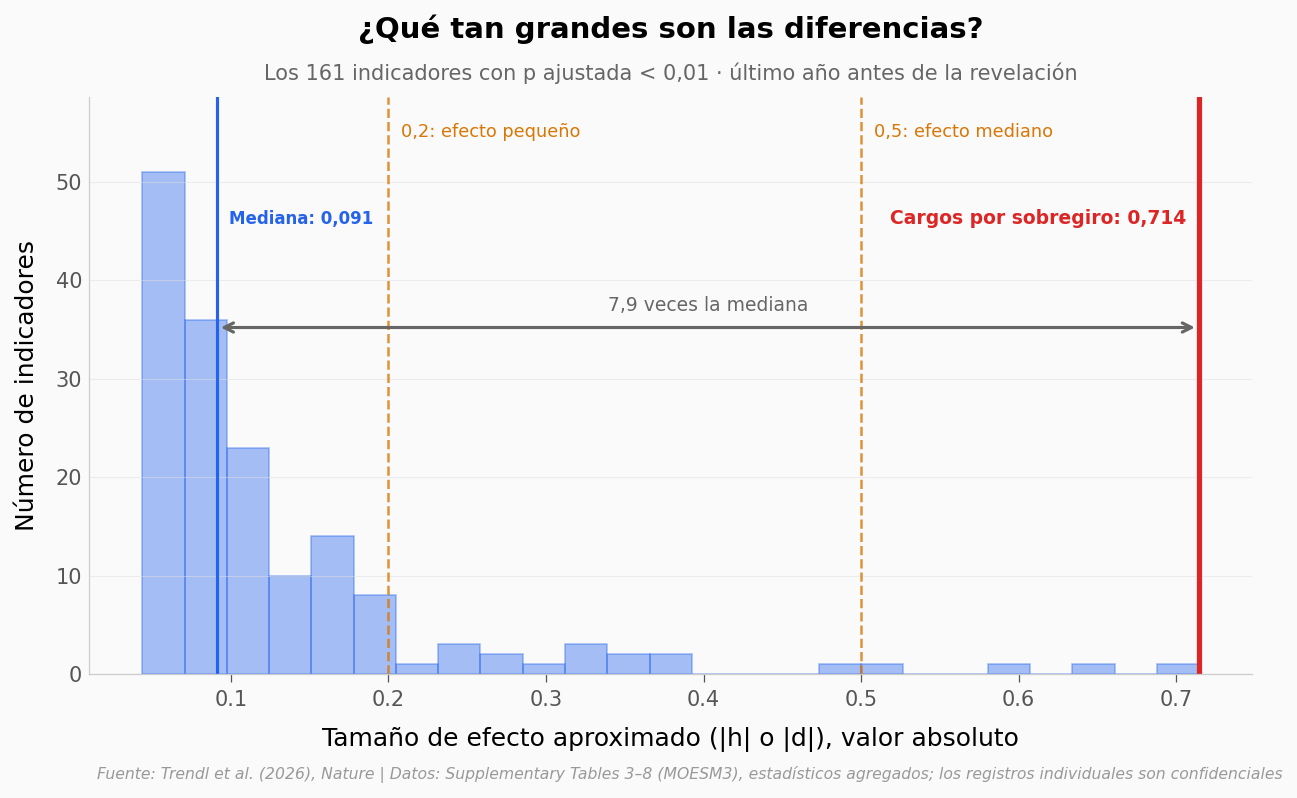

Mediana 0,091 · rango intercuartílico 0,064–0,154
≥ 0,2: 19 de 161 · ≥ 0,5: 4
  Cargos por sobregiro: 0,714
  Débito directo impagado: 0,652
  Cobra Crédito Universal (ayuda social): 0,599
  Sobregiro autorizado: 0,517
n total del estudio: 21.030 personas


In [5]:
mag = sig.set_index('indicador')['tamano_efecto'].abs()
med = mag.median()
q1, q3 = mag.quantile([0.25, 0.75])
top_ind = mag.idxmax()
top = mag.max()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(mag, bins=25, color=COLOR_CONTROL, alpha=0.4, edgecolor=COLOR_CONTROL, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(x=med, color=COLOR_CONTROL, linewidth=1.5)
ax.axvline(x=top, color=COLOR_VICTIMAS, linewidth=2.5)
for u, nombre in [(0.2, 'efecto pequeño'), (0.5, 'efecto mediano')]:
    ax.axvline(x=u, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.8)
    ax.text(u + 0.008, y_max * 0.93, f'{es(u)}: {nombre}', color=COLOR_REFERENCIA, fontsize=8.5)
ax.annotate('', xy=(top, y_max * 0.6), xytext=(med, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((med + top) / 2, y_max * 0.63, f'{es(top / med)} veces la mediana', ha='center', fontsize=9, color='#666666')
ax.text(med + 0.008, y_max * 0.78, f'Mediana: {es(med, 3)}', color=COLOR_CONTROL, fontsize=8, fontweight='bold')
ax.text(top - 0.008, y_max * 0.78, f'{NOMBRES.get(top_ind, top_ind)}: {es(top, 3)}', color=COLOR_VICTIMAS,
        fontsize=9, fontweight='bold', ha='right')
ax.set_xlabel('Tamaño de efecto aproximado (|h| o |d|), valor absoluto')
ax.set_ylabel('Número de indicadores')
ax.set_title('¿Qué tan grandes son las diferencias?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Los {len(sig)} indicadores con p ajustada < {es(UMBRAL_P, 2)} · {NOMBRE_PERIODO[PERIODO]}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_tamano_efecto.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana {es(med, 3)} · rango intercuartílico {es(q1, 3)}–{es(q3, 3)}')
print(f'≥ 0,2: {(mag >= 0.2).sum()} de {len(mag)} · ≥ 0,5: {(mag >= 0.5).sum()}')
for ind, v in mag[mag >= 0.5].sort_values(ascending=False).items():
    print(f'  {NOMBRES.get(ind, ind)}: {es(v, 3)}')
print(f'n total del estudio: {es(n_vs + n_ctl, 0)} personas')

La mayoría de las diferencias son muy pequeñas. La mediana del tamaño de efecto es 0,091 (rango
intercuartílico 0,064–0,154): solo 19 de los 161 llegan a 0,2, lo que por convención se llama un
efecto pequeño, y apenas 4 pasan de 0,5: cargos por sobregiro, débito directo impagado, Crédito
Universal y sobregiro autorizado. Con 21.030 personas, hasta una diferencia mínima sale con p muy
baja; por eso importa el tamaño, no solo la p.

Queda una duda. ¿Y si esto fuera lo que le pasa a cualquiera con problemas de dinero, o a cualquiera
que acaba de separarse? El equipo repitió la comparación con dos grupos control distintos: uno
emparejado por estrés financiero y otro por el fin de una relación.

In [6]:
# La sensibilidad solo existe para el último año: usamos los significativos de esa ventana.
sig_ult = dif[(dif['periodo'] == 'ultimo_anio') & (dif['p_ajustada_bh'] < UMBRAL_P)]['indicador']
MUESTRAS = {'principal': 'Principal',
            'emparejada_por_estres_financiero': 'Control por estrés financiero',
            'emparejada_por_fin_de_relacion': 'Control por fin de relación'}
CLAVE = {'LBG Overdraft charges': 'Cargos por sobregiro (pp)',
         'Unpaid DD': 'Débito directo impagado (pp)',
         'Benefits/Universal Credit/Other': 'Crédito Universal (pp)',
         'Benefits/Disability Living Allowance/Other': 'Ayuda por discapacidad (pp)',
         'Travel/Taxis/Other': 'Taxis (pp)',
         'Motor/Petrol/Other': 'Gasolina (pp)',
         'Services/Health/Dental': 'Dentista (pp)',
         'ATM Withdrawal': 'Retiro en cajero (pp)',
         'Internet Banking': 'Banca por internet (conteo)'}

filas = {}
for ind, nombre in CLAVE.items():
    fila = {}
    for m, etq in MUESTRAS.items():
        r = sens[(sens['muestra'] == m) & (sens['indicador'] == ind)].iloc[0]
        v = r['diferencia'] * (100 if r['unidad'] == 'binary' else 1)
        marca = '' if r['p_ajustada_bh'] < UMBRAL_P else f' (n.s., p {es(r["p_ajustada_bh"], 3)})'
        fila[etq] = f'{"+" if v > 0 else ""}{es(v, 1 if r["unidad"] == "binary" else 2)}{marca}'
    filas[nombre] = fila
print('Diferencia víctimas − control, último año (n.s. = p ajustada ≥ umbral)\n')
print(pd.DataFrame(filas).T.to_string())

print()
base = sens[sens['muestra'] == 'principal'].set_index('indicador')['diferencia'].loc[sig_ult]
for m, etq in list(MUESTRAS.items())[1:]:
    s = sens[sens['muestra'] == m]
    otra = s.set_index('indicador')['diferencia'].loc[sig_ult]
    misma = (np.sign(otra) == np.sign(base)).mean() * 100
    print(f'{etq}: n = {es(s["n_vs"].mode()[0], 0)} / {es(s["n_control"].mode()[0], 0)} · '
          f'{es(misma)} % de los {len(sig_ult)} con la misma dirección · '
          f'{(s["p_ajustada_bh"] < UMBRAL_P).sum()} significativos')

Diferencia víctimas − control, último año (n.s. = p ajustada ≥ umbral)

                             Principal Control por estrés financiero Control por fin de relación
Cargos por sobregiro (pp)        +34,6          -0,2 (n.s., p 0,848)                       +32,7
Débito directo impagado (pp)     +31,9          -2,2 (n.s., p 0,012)                       +26,5
Crédito Universal (pp)           +28,4                         +22,1                       +20,0
Ayuda por discapacidad (pp)       +7,9                         +14,3                        +5,2
Taxis (pp)                       +12,3                          +2,5                       +12,0
Gasolina (pp)                     +5,0          +0,8 (n.s., p 0,344)                       +10,1
Dentista (pp)                     -8,8                          -3,4        -4,3 (n.s., p 0,012)
Retiro en cajero (pp)             +4,0                          +3,5                        +7,0
Banca por internet (conteo)     +10,08                 

Con el control emparejado por estrés financiero, el 84,5 % de los 161 indicadores mantiene la
dirección; con el de fin de relación, el 86,3 %.

En la muestra de estrés financiero, los cargos por sobregiro se igualan
(−0,2 puntos, p ajustada 0,848) y los débitos impagados casi (−2,2 puntos, p ajustada 0,012, justo por
encima del umbral de 0,01). Es esperable por diseño: ese grupo control se emparejó usando
justamente esas variables, medidas 12 meses antes de la revelación. Lo interesante es lo que cambia
sin haberse forzado: los taxis bajan de +12,3 a +2,5 puntos, la gasolina deja de ser significativa
(+0,8), el dentista se reduce a −3,4 y la banca por internet se invierte. En cambio, cobrar ayuda por
discapacidad sube de +7,9 a +14,3 puntos. Parte del patrón, entonces, también aparece en mujeres con un nivel parecido de
estrés financiero que no le reportaron abuso al banco.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las víctimas-sobrevivientes pagan cargos por sobregiro con más frecuencia que el control en el último año | ✅ | 74,5 % vs. 39,9 % (+34,6 pp, IC 95 % 33,2–36,0; p ajustada < 0,001). Tamaño de efecto h ≈ 0,71, el mayor de los 161 |
| Tienen menos ahorro y peor puntaje de crédito | ✅ | Último año: ahorro −£3.501 (n = 4.149 vs. 12.181, solo quienes tienen cuenta de ahorro); puntaje 767 vs. 876 (−109 puntos) |
| Más de la mitad de las diferencias ya existían entre 7 y 3,5 años antes de la revelación, y la mayoría crece después | ✅ | 88 de 161 ya eran significativas entre 7 y 3,5 años antes; 142 de 159 tienen un efecto mayor en la ventana 3,5–0 con el mismo signo que el último año (133 en unidades originales; 126 mantienen el signo en las tres ventanas) |
| Gastan menos en autocuidado y más en transporte y servicios legales | ⚠️ | Dentista −8,8 pp, ropa de mujer −8,5, deporte −5,3; taxis +12,3, servicios legales +5,9. Con el control por estrés financiero, taxis cae a +2,5 y dentista a −3,4 |
| El patrón se mantiene con grupos control alternativos | ⚠️ | 84,5 % (estrés financiero) y 86,3 % (fin de relación) de los 161 van en la misma dirección, pero la banca por internet se invierte y la gasolina deja de ser significativa. Sobregiro y débito impagado se igualan o casi, algo esperable porque ese control se emparejó con esas variables |
| La mayoría de las 161 diferencias son grandes | ❌ | Mediana del tamaño de efecto 0,091 (rango intercuartílico 0,064–0,154); 19 llegan a 0,2 y solo 4 pasan de 0,5 |
| El abuso financiero causa estas diferencias | ❌ | Estudio observacional. Los autores concluyen que las víctimas pierden independencia financiera, pero el diseño no aísla la causa |

> **Limitaciones:**
> - Solo mujeres que le contaron al banco que sufrían abuso financiero, en un banco del Reino Unido. Quienes lo revelan no son una muestra al azar de todas las víctimas.
> - Trabajamos con estadísticos agregados: los registros individuales son confidenciales, así que no podemos recalcular las pruebas, solo leerlas. El repositorio de código del paper genera un conjunto de datos *sintético*; no lo usamos porque no son datos observados.
> - Los indicadores transaccionales miden la proporción con al menos un movimiento en la ventana, y eso depende de su largo: no se comparan los niveles del último año con los de las ventanas de 3,5 años.
> - El emparejamiento iguala lo que se midió 7 años antes (la edad media pasa de 35,2 vs. 44,5 años a 35,3 vs. 34,9), no lo que no se midió.
> - El tamaño de efecto es un cálculo nuestro aproximado (h de Cohen para proporciones, d aproximada desde el estadístico t para el resto); el paper no lo reporta. Es una simplificación didáctica: un análisis formal usaría los registros individuales.
> - Las p vienen de pruebas de permutación con corrección de Benjamini-Hochberg aplicada a la vez a las tres ventanas de la muestra principal (1.117 pruebas: 373 indicadores × 3 ventanas, menos 2 sin dato).

### Ahora tú

1. **¿Cuántos indicadores saldrían «significativos» con un umbral más laxo?** Cambia `UMBRAL_P = 0.05`
   en la celda de configuración y vuelve a ejecutar todo. ¿Cambia la forma del histograma?
2. **¿Qué parte de la vida financiera concentra más diferencias?** Pista: `sig.groupby('categoria').size().sort_values()`.
3. **¿Qué pasa con las apuestas, las donaciones o los préstamos rápidos?** La celda de abajo busca cualquier
   indicador por una palabra: prueba `'Charity'`, `'Payday'` o `'Child'` (gastos relacionados con hijos).

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Busca indicadores por una palabra (en inglés, como los nombra el banco) y míralos en las 3 ventanas.
PALABRA = 'Gambling'
UNIDADES = {'count': 'conteo', 'score': 'puntaje', 'pound': 'libras (£)'}

encontrados = dif[dif['indicador'].str.contains(PALABRA, case=False, regex=False)]
if encontrados.empty:
    print(f'Ningún indicador contiene «{PALABRA}»')
for ind, g in encontrados.groupby('indicador'):
    g = g.set_index('periodo').loc[PERIODOS]
    binario = g['unidad'].iloc[0] == 'binary'
    print(f'\n{ind}  ({"% con al menos un movimiento" if binario else UNIDADES.get(g["unidad"].iloc[0], g["unidad"].iloc[0])})')
    for p, r in g.iterrows():
        f = 100 if binario else 1
        marca = '✱' if r['p_ajustada_bh'] < UMBRAL_P else ' '
        print(f'  {marca} {NOMBRE_PERIODO[p]:<46} víctimas {es(r["vs_media"] * f, 2):>9} · '
              f'control {es(r["control_media"] * f, 2):>9} · p ajustada {es(r["p_ajustada_bh"], 3)}')
print(f'\n✱ = p ajustada < {es(UMBRAL_P, 2)}')


Hobbies & Interests/Gambling/Other  (% con al menos un movimiento)
    entre 7 y 3,5 años antes de la revelación      víctimas     54,24 · control     53,42 · p ajustada 0,416
    entre 3,5 y 0 años antes de la revelación      víctimas     61,53 · control     60,12 · p ajustada 0,139
    último año antes de la revelación              víctimas     44,97 · control     46,91 · p ajustada 0,042

Income/Gambling/Other  (% con al menos un movimiento)
    entre 7 y 3,5 años antes de la revelación      víctimas     11,68 · control     11,16 · p ajustada 0,434
    entre 3,5 y 0 años antes de la revelación      víctimas     13,39 · control     13,93 · p ajustada 0,448
  ✱ último año antes de la revelación              víctimas      6,89 · control      8,23 · p ajustada 0,007

✱ = p ajustada < 0,01


---

**Datos:** Supplementary Tables 3–8 del paper (MOESM3): medias ponderadas, intervalos de confianza y
pruebas de los 373 indicadores en la muestra principal y en las dos muestras de sensibilidad, medias
de la clientela del banco y balance del emparejamiento. Los registros bancarios individuales son
confidenciales y no están disponibles.

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-23-abuso-financiero-registros-bancarios)

## Fuentes

**Paper**: [Banking records reveal characteristics of financial abuse](https://doi.org/10.1038/s41586-026-11049-7)  
*Nature, 2026-09-23*

**Supplementary Material**: [Supplementary Tables 3–10 for Banking records reveal characteristics of financial abuse (MOESM3)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11049-7/MediaObjects/41586_2026_11049_MOESM3_ESM.zip)  
*Nature, 2026-09-23*

**Supplementary Material**: [Supplementary Information for Banking records reveal characteristics of financial abuse (MOESM1)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11049-7/MediaObjects/41586_2026_11049_MOESM1_ESM.pdf)  
*Nature, 2026-09-23*

*22 afirmaciones del notebook verificadas contra estas fuentes*